In [22]:
import torchaudio
import torchaudio.transforms as T
import scipy.io as sio
import pandas as pd
import numpy as np
import sys, os
import torch
project_root = os.path.abspath(os.path.join(os.getcwd(), os.pardir))
if project_root not in sys.path:
    sys.path.insert(0, project_root)
from data_classes.decomposition import Extract_Features

In [23]:
# load & preprocess
data = sio.loadmat('../data/mine_impact_data_2019.mat')
samps = pd.DataFrame(data['x'].T)
labs  = pd.DataFrame(data['y'].T, columns=['y'])
df = pd.concat([samps, labs], axis=1).dropna().sample(frac=1, random_state=42)

In [24]:
shuffled_df = df.sample(frac=1, random_state=42).reset_index(drop=True)

df_X = shuffled_df.iloc[:, :-1]
df_Y = shuffled_df.iloc[:, -1]

data = Extract_Features(df_X, df_Y, feature="raw")
print(data.get_samples().shape, data.get_labels().shape)

(3309, 36000) (3309,)


In [5]:
from IPython.display import Audio
from matplotlib.patches import Rectangle
from torchaudio.utils import download_asset
import matplotlib.pyplot as plt
import librosa

torch.random.manual_seed(0)

SAMPLE_SPEECH = download_asset("tutorial-assets/Lab41-SRI-VOiCES-src-sp0307-ch127535-sg0042.wav")


def plot_waveform(waveform, sr, title="Waveform", ax=None):
    waveform = waveform.numpy()

    num_channels, num_frames = waveform.shape
    time_axis = torch.arange(0, num_frames) / sr

    if ax is None:
        _, ax = plt.subplots(num_channels, 1)
    ax.plot(time_axis, waveform[0], linewidth=1)
    ax.grid(True)
    ax.set_xlim([0, time_axis[-1]])
    ax.set_title(title)


def plot_spectrogram(specgram, title=None, ylabel="freq_bin", ax=None):
    if ax is None:
        _, ax = plt.subplots(1, 1)
    if title is not None:
        ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.imshow(librosa.power_to_db(specgram), origin="lower", aspect="auto", interpolation="nearest")


def plot_fbank(fbank, title=None):
    fig, axs = plt.subplots(1, 1)
    axs.set_title(title or "Filter bank")
    axs.imshow(fbank, aspect="auto")
    axs.set_ylabel("frequency bin")
    axs.set_xlabel("mel bin")


 Label: 1
 Spectrogram shape: torch.Size([1, 257, 141])


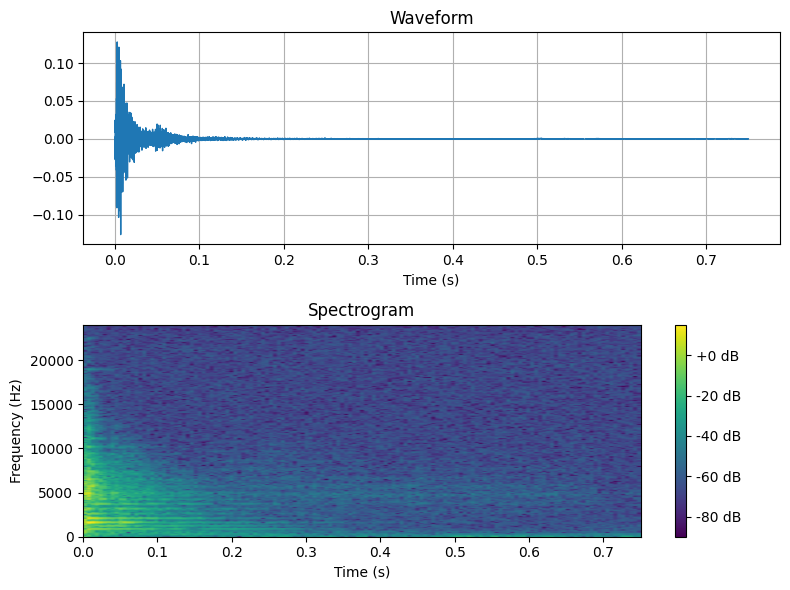

In [19]:
import torch
import torchaudio.transforms as T
import matplotlib.pyplot as plt

# 1) grab your first row of samples and convert to a float32 Tensor
samples = df_X.iloc[0].values.astype('float32')
labels = df_Y.iloc[0]
print(f" Label: {labels}")
waveform = torch.from_numpy(samples).unsqueeze(0)   # shape (1, 36000)

# 2) set the sampling rate
sr = 48000

# 3) make a spectrogram transform
spectrogram = T.Spectrogram(
    n_fft=512,
    power=2.0
)

# 4) apply it
spec = spectrogram(waveform)   # shape (1, freq_bins, time_steps)
print(f" Spectrogram shape: {spec.shape}")

# 5) plot
fig, (ax_wf, ax_sp) = plt.subplots(2, 1, figsize=(8, 6))

# waveform
time = torch.arange(waveform.size(1)) / sr
ax_wf.plot(time, waveform[0].numpy(), linewidth=1)
ax_wf.set_title("Waveform")
ax_wf.set_xlabel("Time (s)")
ax_wf.grid(True)

# spectrogram (in dB)
spec_db = 10 * torch.log10(spec[0] + 1e-9)
img = ax_sp.imshow(
    spec_db.numpy(), 
    origin='lower', 
    aspect='auto', 
    extent=[0, time[-1], 0, sr/2]
)
ax_sp.set_title("Spectrogram")
ax_sp.set_xlabel("Time (s)")
ax_sp.set_ylabel("Frequency (Hz)")
fig.colorbar(img, ax=ax_sp, format="%+2.0f dB")

plt.tight_layout()
plt.show()

In [25]:

from scipy.fftpack import dct

y, sr = data.get_samples()[0], 48000
cent = librosa.feature.spectral_centroid(y=y, sr=sr,n_fft=128, hop_length=128)
cent.shape


data.X_reduced = np.squeeze(librosa.feature.spectral_centroid(y=data.get_samples(), sr=sr,n_fft=512, hop_length=64))
scmcs = dct(data.X_reduced, type=2, norm='ortho')

In [26]:
data.X_reduced = scmcs

print(data.get_samples().shape, data.get_labels().shape)

(3309, 563) (3309,)


[INFO] EPOCH: 1/40
Train loss: 9.808955, Train accuracy: 0.6293
[INFO] EPOCH: 2/40
Train loss: 0.600656, Train accuracy: 0.6773
[INFO] EPOCH: 3/40
Train loss: 0.576847, Train accuracy: 0.7067
[INFO] EPOCH: 4/40
Train loss: 0.572488, Train accuracy: 0.6987
[INFO] EPOCH: 5/40
Train loss: 0.530256, Train accuracy: 0.7223
[INFO] EPOCH: 6/40
Train loss: 0.526893, Train accuracy: 0.7313
[INFO] EPOCH: 7/40
Train loss: 0.502974, Train accuracy: 0.7323
[INFO] EPOCH: 8/40
Train loss: 0.491148, Train accuracy: 0.7463
[INFO] EPOCH: 9/40
Train loss: 0.486064, Train accuracy: 0.7400
[INFO] EPOCH: 10/40
Train loss: 0.468853, Train accuracy: 0.7503
[INFO] EPOCH: 11/40
Train loss: 0.462964, Train accuracy: 0.7463
[INFO] EPOCH: 12/40
Train loss: 0.448019, Train accuracy: 0.7580
[INFO] EPOCH: 13/40
Train loss: 0.436328, Train accuracy: 0.7683
[INFO] EPOCH: 14/40
Train loss: 0.430876, Train accuracy: 0.7673
[INFO] EPOCH: 15/40
Train loss: 0.431041, Train accuracy: 0.7677
[INFO] EPOCH: 16/40
Train loss: 0.

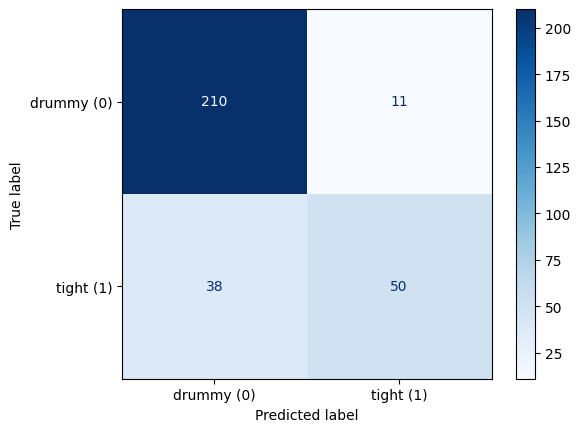


Classification Report:
               precision    recall  f1-score   support

  drummy (0)       0.85      0.95      0.90       221
   tight (1)       0.82      0.57      0.67        88

    accuracy                           0.84       309
   macro avg       0.83      0.76      0.78       309
weighted avg       0.84      0.84      0.83       309



In [32]:
import models.classification as classify
import models.loops as loops

train_idx = list(range(0, 3000))
test_idx = list(range(3000,3309))

train_data = torch.utils.data.Subset(data, train_idx)
test_data = torch.utils.data.Subset(data, test_idx)

batch_size = 30

train_loader = torch.utils.data.DataLoader(train_data, batch_size=batch_size, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_data, batch_size=batch_size, shuffle=True)

model = classify.MLP_3_layer(nb_hidden=128, input_dim=data.get_samples().shape[1], output_dim=2, dropout_rate=0.5)

loops.train(model=model, model_path="./model_paths/spec.pth", train_loader=train_loader, batch_size=batch_size, lr=1e-3, weight_decay=1e-3, optim="adam", epochs=40)

loops.test(model_path="./model_paths/spec.pth", test_loader=test_loader, report= True)